# Reversal Failure & Error Analysis — DBS Stimulation
### Digit Span Backwards: Session 2, Session 3, Combined

**Analyses covered:**
1. **Reversal Failure × STIM** — Completely-off-stim vs stim-on reversal trials (S2, S3, S2+S3)
2. **Intrusion Errors** — Trials where patient entered a digit NOT shown in the trial
3. **Easy vs Hard Difficulty × Stim State** — 4 combinations with stats

**Error Taxonomy:**
- `CORRECT` — ACC=1
- `NO_REVERSAL_exact` — Response == presented order (complete reversal failure)
- `NO_REVERSAL_partial` — First digit of response ≠ last digit of presented
- `PARTIAL_REVERSAL` — Started correctly (resp[0]==presented[-1]) but rest wrong
- `OTHER_ERROR` — Incorrect, doesn't fit above

**Encoding note:** `CRESP` = correct reversed answer. Presented = `str(int(CRESP)).zfill(N)[::-1]`

In [ ]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import json
from scipy import stats
from scipy.stats import fisher_exact
import warnings
warnings.filterwarnings('ignore')

# ── Colour scheme (matches supervisor pipeline) ──────────────────────────
COL_C   = '#2166AC'   # correct / stim-off
COL_I   = '#D6604D'   # incorrect / stim-on
COL_NS  = '#AAAAAA'   # no-stim bar
COL_ST  = '#2B7BB9'   # stim-on bar
ALPHA_SCATTER = 0.75

# ── File paths ───────────────────────────────────────────────────────────
FILES = {
    2: {
        'beh'    : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-2-Scores.csv',
        'events' : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Session 2\Events.csv',
        'json'   : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1433\Report_Json_Session_Report_20260305T151703.json',
    },
    3: {
        'beh'    : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Eprime Data\Digit Span Backwards v3.2\DigitSpanBackward v3.3-6-3-Scores.csv',
        'events' : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Session 3\Preprocessed Data\Events.csv',
        'json'   : r'C:\Users\ASSUS\ATN\Digit Span Backwards\Data\Neural Data\DBS ATN DSB Case 1\D. Siragusa\3.5.26\Time stamp 1441\Report_Json_Session_Report_20260305T151912.json',
    },
}

STIM_THRESH_MA = 2.0    # mA threshold for STIM-ON
STIM_FRAC      = 0.50   # fraction of window that must be ≥ threshold
EASY_DIGITS    = [2,3] # 'easy' difficulty
HARD_DIGITS    = [4] # 'hard' difficulty
print('Config OK')

Config OK


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 2 — HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════

def rttime_to_sample(rttime_ms):
    return (rttime_ms - 73_455) / 4.0

def cohens_d(a, b):
    """Cohen's d (pooled SD). Returns NaN if insufficient data."""
    a, b = np.asarray(a, float), np.asarray(b, float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    n1, n2 = len(a), len(b)
    sp = np.sqrt(((n1-1)*np.var(a, ddof=1) + (n2-1)*np.var(b, ddof=1)) / (n1+n2-2))
    return (np.mean(a) - np.mean(b)) / sp if sp > 0 else np.nan

def effect_label(d):
    if np.isnan(d): return 'N/A'
    a = abs(d)
    if a < 0.2: return 'negligible'
    if a < 0.5: return 'small'
    if a < 0.8: return 'medium'
    return 'large'

def sig_stars(p):
    if np.isnan(p): return 'N/A'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

def stat_box_color(p, d):
    """Red box if significant OR large effect."""
    sig = (not np.isnan(p) and p < 0.05)
    eff = (not np.isnan(d) and abs(d) >= 0.8)
    return '#CC0000' if (sig or eff) else '#444444'

def format_stat_line(p, d, n_off, n_on):
    stars = sig_stars(p)
    eff   = effect_label(d)
    d_str = f'd={d:+.2f}' if not np.isnan(d) else 'd=N/A'
    p_str = f'p={p:.4f}' if not np.isnan(p) else 'p=N/A'
    return f'{stars}  {p_str}  {d_str}  Effect: {eff}'

def classify_error(row, n_digits):
    """Classify response into error type."""
    if row['ACC'] == 1:
        return 'CORRECT'
    try:
        cresp = str(int(row['CRESP'])).zfill(n_digits)
        resp  = str(int(row['RESP'])).zfill(n_digits)
        pres  = cresp[::-1]
        if resp == pres:
            return 'NO_REVERSAL_exact'
        elif resp[0] != pres[-1]:
            return 'NO_REVERSAL_partial'
        else:
            return 'PARTIAL_REVERSAL'
    except Exception:
        return 'OTHER_ERROR'

def has_intrusion(row, n_digits):
    """True if response contains a digit NOT in the presented sequence."""
    if row['ACC'] == 1:
        return False
    try:
        cresp = str(int(row['CRESP'])).zfill(n_digits)
        resp  = str(int(row['RESP'])).zfill(n_digits)
        pres  = cresp[::-1]
        presented_set = set(pres)
        for ch in resp:
            if ch not in presented_set:
                return True
        return False
    except Exception:
        return False

def get_intrusion_digits(row, n_digits):
    """Return list of digits in response NOT in presented."""
    try:
        cresp = str(int(row['CRESP'])).zfill(n_digits)
        resp  = str(int(row['RESP'])).zfill(n_digits)
        pres  = cresp[::-1]
        presented_set = set(pres)
        return [ch for ch in resp if ch not in presented_set]
    except Exception:
        return []

print('Helpers OK')

Helpers OK


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 3 — LOAD & PARSE DATA  (Medtronic Percept PC pipeline)
# ═══════════════════════════════════════════════════════════════════════════

def _stim_frac(t0, t1, ticks_rel, mAs, thresh=STIM_THRESH_MA):
    """Fraction of [t0,t1] with mA >= thresh. Nearest-sample fallback."""
    if t0 is None or t1 is None or t1 <= t0: return 0.0
    mask = (ticks_rel >= t0) & (ticks_rel <= t1)
    tr, tm = ticks_rel[mask], mAs[mask]
    if len(tr) < 2:
        idx = int(np.argmin(np.abs(ticks_rel - (t0+t1)/2)))
        return 1.0 if mAs[idx] >= thresh else 0.0
    dt = np.diff(tr); mid = (tm[:-1]+tm[1:])/2
    total = tr[-1]-tr[0]
    if total <= 0: return 1.0 if tm[0] >= thresh else 0.0
    return float(np.sum(dt[mid >= thresh]) / total)


def load_session(sess_id):
    f   = FILES[sess_id]
    beh = pd.read_csv(f['beh'],    encoding='utf-8-sig', low_memory=False)
    ev  = pd.read_csv(f['events'], encoding='utf-8-sig', low_memory=False)
    with open(f['json'], 'r') as jf:
        jdata = json.load(jf)

    # ── Alignment anchor: first Left mA 0→>0 transition ──────────────────
    stim_tick = None
    for stream in jdata['BrainSenseLfp']:
        prev = None
        for pkt in stream['LfpData']:
            curr = pkt['Left']['mA']
            if prev is not None and prev == 0.0 and curr > 0.0:
                stim_tick = pkt['TicksInMs']; break
            prev = curr
        if stim_tick: break
    assert stim_tick, f'S{sess_id}: No 0->0 mA transition found!'

    welcome_ms = int(beh['Welcome.TargetOnsetTime'].iloc[0])
    _offset    = stim_tick - welcome_ms
    def to_rel(ms): return float(ms) + _offset - stim_tick

    # ── mA trace ─────────────────────────────────────────────────────────
    ticks, mAs = [], []
    for stream in jdata['BrainSenseLfp']:
        for pkt in stream['LfpData']:
            ticks.append(pkt['TicksInMs'])
            mAs.append(pkt['Left']['mA'])
    ticks = np.array(ticks, float); mAs_arr = np.array(mAs, float)
    order = np.argsort(ticks)
    ticks_rel = ticks[order] - stim_tick
    mAs_arr   = mAs_arr[order]

    # ── Per-trial extraction ──────────────────────────────────────────────
    def ev_first(etype, tn):
        r = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
        return to_rel(float(r.iloc[0]['Time_ms'])) if not r.empty else None

    def ev_all_rel(etype, tn):
        r = ev[(ev['Event_Type']==etype) & (ev['Trial_Number']==tn)]
        return [to_rel(float(x)) for x in r['Time_ms'].tolist()]

    trials = []
    for tn in range(1, 15):
        sr = ev[(ev['Event_Type']=='Main Trial Start') & (ev['Trial_Number']==tn)]
        if sr.empty: continue
        r = sr.iloc[0]
        acc     = int(r['ACC'])        if pd.notna(r['ACC'])        else None
        nd      = int(r['Num_Digits']) if pd.notna(r['Num_Digits']) else None
        cresp_v = r['CRESP']           if pd.notna(r['CRESP'])      else None
        resp_v  = r['RESP']            if pd.notna(r['RESP'])       else None
        if None in (acc, nd, cresp_v, resp_v): continue

        t_start = ev_first('Main Trial Start', tn)
        t_end   = ev_first('Main Trial End',   tn)
        cs      = ev_first('Choice Start',     tn)
        ce      = ev_first('Choice End',       tn)
        fb_s    = ev_first('Feedback Start',   tn)
        fb_e    = ev_first('Feedback End',     tn)

        fix_starts  = ev_all_rel('Fixation Start', tn)
        stim_starts = ev_all_rel('Stimulus Start', tn)
        stim_ends   = ev_all_rel('Stimulus End',   tn)

        # Per-window stim fractions
        fix_fracs   = [_stim_frac(fs, ss, ticks_rel, mAs_arr)
                       for fs, ss in zip(fix_starts, stim_starts)]
        stim_fracs  = [_stim_frac(ss, se, ticks_rel, mAs_arr)
                       for ss, se in zip(stim_starts, stim_ends)]
        ch_frac     = _stim_frac(cs,      ce,    ticks_rel, mAs_arr)
        fb_frac     = _stim_frac(fb_s,    fb_e,  ticks_rel, mAs_arr)
        trial_frac  = _stim_frac(t_start, t_end, ticks_rel, mAs_arr)

        stim_on_trial  = trial_frac >= STIM_FRAC
        stim_on_choice = ch_frac    >= STIM_FRAC
        stim_on_fix    = any(f >= STIM_FRAC for f in fix_fracs)
        stim_on_stim   = any(f >= STIM_FRAC for f in stim_fracs)
        stim_on_fb     = fb_frac    >= STIM_FRAC

        # Error classification via dummy object
        row ={
            'ACC': acc,
            'CRESP': cresp_v,
            'RESP': resp_v
        }
        error_type       = classify_error(row, nd)
        intrusion        = has_intrusion(row, nd)
        intr_digs        = get_intrusion_digits(row, nd)
        reversal_failure = error_type in ['NO_REVERSAL_exact','NO_REVERSAL_partial','PARTIAL_REVERSAL']
        difficulty       = 'Easy' if nd in EASY_DIGITS else 'Hard'

        trials.append(dict(
            session=sess_id, trial=tn, num_digits=nd, acc=acc,
            error_type=error_type, reversal_failure=reversal_failure,
            intrusion=intrusion, intrusion_digits=intr_digs,
            stim_on=stim_on_trial, stim_on_choice=stim_on_choice,
            stim_on_fix=stim_on_fix, stim_on_stim=stim_on_stim,
            stim_on_fb=stim_on_fb,
            peak_ma=float(trial_frac), difficulty=difficulty,
            cresp=str(int(cresp_v)).zfill(nd),
            resp=str(int(resp_v)).zfill(nd),
        ))

    return pd.DataFrame(trials)


print('Loading Session 2...')
df2 = load_session(2)
print(f'  S2: {len(df2)} trials loaded')
print('Loading Session 3...')
df3 = load_session(3)
print(f'  S3: {len(df3)} trials loaded')

df_all = pd.concat([df2, df3], ignore_index=True)
print(f'  Combined: {len(df_all)} trials')
df_all[['session','trial','num_digits','acc','error_type','stim_on','difficulty','intrusion']].head(8)

Loading Session 2...
  S2: 14 trials loaded
Loading Session 3...
  S3: 14 trials loaded
  Combined: 28 trials


,session,trial,num_digits,acc,error_type,stim_on,difficulty,intrusion
0,2,1,2,1,CORRECT,False,Easy,False
1,2,2,2,1,CORRECT,False,Easy,False
2,2,3,3,1,CORRECT,False,Hard,False
3,2,4,3,1,CORRECT,False,Hard,False
4,2,5,4,1,CORRECT,False,Hard,False
5,2,6,4,0,PARTIAL_REVERSAL,False,Hard,True
6,2,7,4,0,PARTIAL_REVERSAL,True,Hard,False
7,2,8,4,0,NO_REVERSAL_partial,True,Hard,False


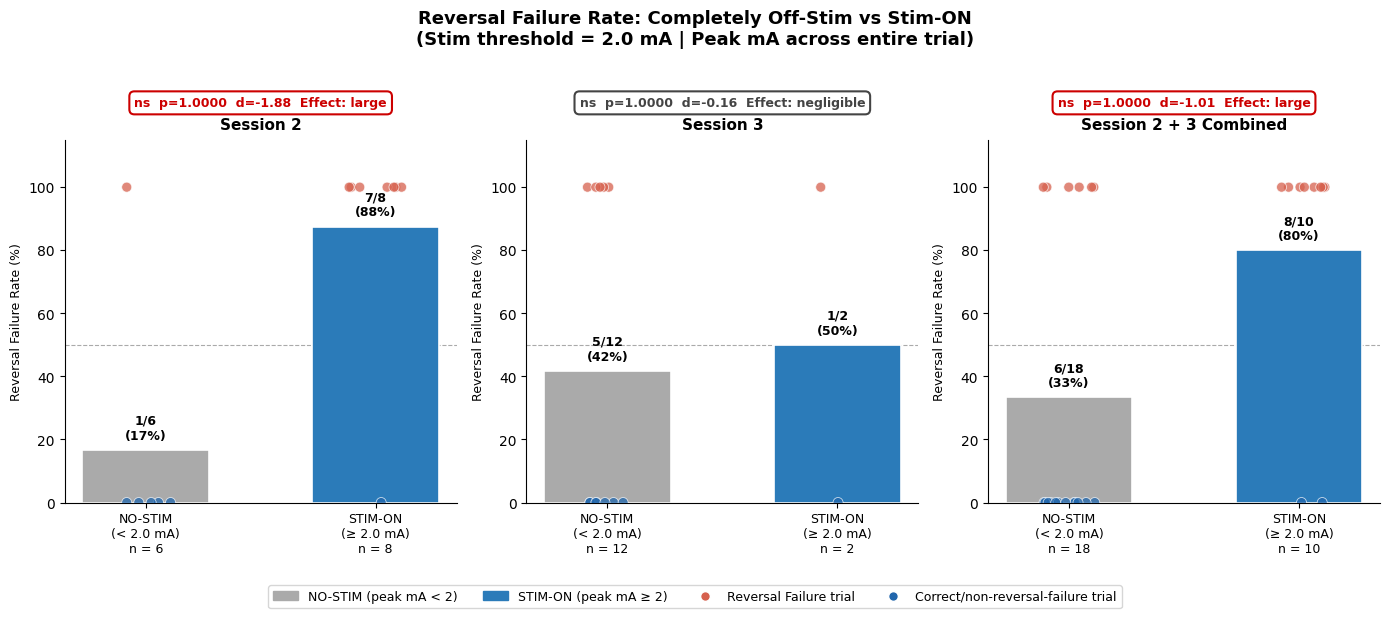

Plot 1 saved: plot1_reversal_failure_stim.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 4 — REVERSAL FAILURE × STIM: per session + combined
# ═══════════════════════════════════════════════════════════════════════════
# Filter: only trials classified as any reversal error
#   Completely off-stim = stim_on==False (peak mA < 2 mA)
#   Stim-on            = stim_on==True
# Stats: Fisher's Exact (binary outcome = reversal_failure)
#        Cohen's d on binary acc vector

def reversal_stats_plot(df_subset, ax, title, session_label):
    """Bar + jitter plot: NO-STIM vs STIM-ON for reversal failures."""
    off = df_subset[~df_subset['stim_on']]
    on  = df_subset[ df_subset['stim_on']]

    n_off, n_on = len(off), len(on)
    rf_off = off['reversal_failure'].mean() * 100 if n_off else np.nan
    rf_on  = on['reversal_failure'].mean()  * 100 if n_on  else np.nan

    # Stats
    if n_off >= 1 and n_on >= 1:
        ct = pd.crosstab(df_subset['stim_on'], df_subset['reversal_failure'])
        # Ensure 2×2
        for col in [True, False]:
            if col not in ct.columns: ct[col] = 0
        ct = ct[[False, True]]
        _, pval = fisher_exact([[ct.loc[False, True], ct.loc[False, False]],
                                  [ct.loc[True,  True], ct.loc[True,  False]]]
                                 if False in ct.index and True in ct.index else [[0,1],[0,1]])
        d = cohens_d(off['reversal_failure'].astype(float), on['reversal_failure'].astype(float))
    else:
        pval, d = np.nan, np.nan

    # ── Bars ──
    xs = [0, 1]
    ys = [rf_off if not np.isnan(rf_off) else 0,
          rf_on  if not np.isnan(rf_on)  else 0]
    bars = ax.bar(xs, ys, width=0.55, color=[COL_NS, COL_ST],
                  edgecolor='white', linewidth=1.2, zorder=2)

    # ── Jitter (per-trial dots) ──
    for xi, grp in zip(xs, [off, on]):
        yy  = grp['reversal_failure'].astype(float) * 100
        jit = np.random.uniform(-0.12, 0.12, len(yy))
        cols = [COL_I if rf else COL_C for rf in grp['reversal_failure']]
        ax.scatter(xi + jit, yy, c=cols, s=52, zorder=5,
                   edgecolors='white', linewidths=0.6, alpha=ALPHA_SCATTER)

    # ── Labels on bars ──
    n_rf_off = off['reversal_failure'].sum()
    n_rf_on  = on['reversal_failure'].sum()
    for xi, nb, nt, pct in zip(xs,
                                [n_rf_off, n_rf_on],
                                [n_off, n_on],
                                [rf_off, rf_on]):
        if not np.isnan(pct):
            ax.text(xi, pct + 2.5, f'{int(nb)}/{nt}\n({pct:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # ── Axes ──
    ax.set_xticks(xs)
    ax.set_xticklabels([
        f'NO-STIM\n(< {STIM_THRESH_MA} mA)\nn = {n_off}',
        f'STIM-ON\n(≥ {STIM_THRESH_MA} mA)\nn = {n_on}'
    ], fontsize=9)
    ax.set_ylabel('Reversal Failure Rate (%)', fontsize=9)
    ax.set_ylim(0, 115)
    ax.axhline(50, ls='--', lw=0.8, color='#AAAAAA', zorder=1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

    # ── Stat box ──
    stat_str = format_stat_line(pval, d, n_off, n_on)
    box_col  = stat_box_color(pval, d)
    ax.text(0.5, 1.12, stat_str, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=box_col,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=box_col, linewidth=1.5))
    return pval, d

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), facecolor='white')
fig.suptitle('Reversal Failure Rate: Completely Off-Stim vs Stim-ON\n'
             f'(Stim threshold = {STIM_THRESH_MA} mA | Peak mA across entire trial)',
             fontsize=13, fontweight='bold', y=1.02)

# Only reversal trials (any error that is a reversal failure)
for ax, (df_s, lbl) in zip(axes, [(df2, 'Session 2'),
                                    (df3, 'Session 3'),
                                    (df_all, 'Session 2 + 3 Combined')]):
    # Filter: only incorrect trials (reversal failures vs correct within stim groups)
    # Use ALL trials so we can compute reversal failure RATE
    reversal_stats_plot(df_s, ax, lbl, lbl)

# Legend
handles = [
    mpatches.Patch(color=COL_NS,  label='NO-STIM (peak mA < 2)'),
    mpatches.Patch(color=COL_ST,  label='STIM-ON (peak mA ≥ 2)'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_I,
               markeredgecolor='white', markersize=7, label='Reversal Failure trial'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_C,
               markeredgecolor='white', markersize=7, label='Correct/non-reversal-failure trial'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))

plt.tight_layout()
plt.savefig('plot1_reversal_failure_stim.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print('Plot 1 saved: plot1_reversal_failure_stim.png')

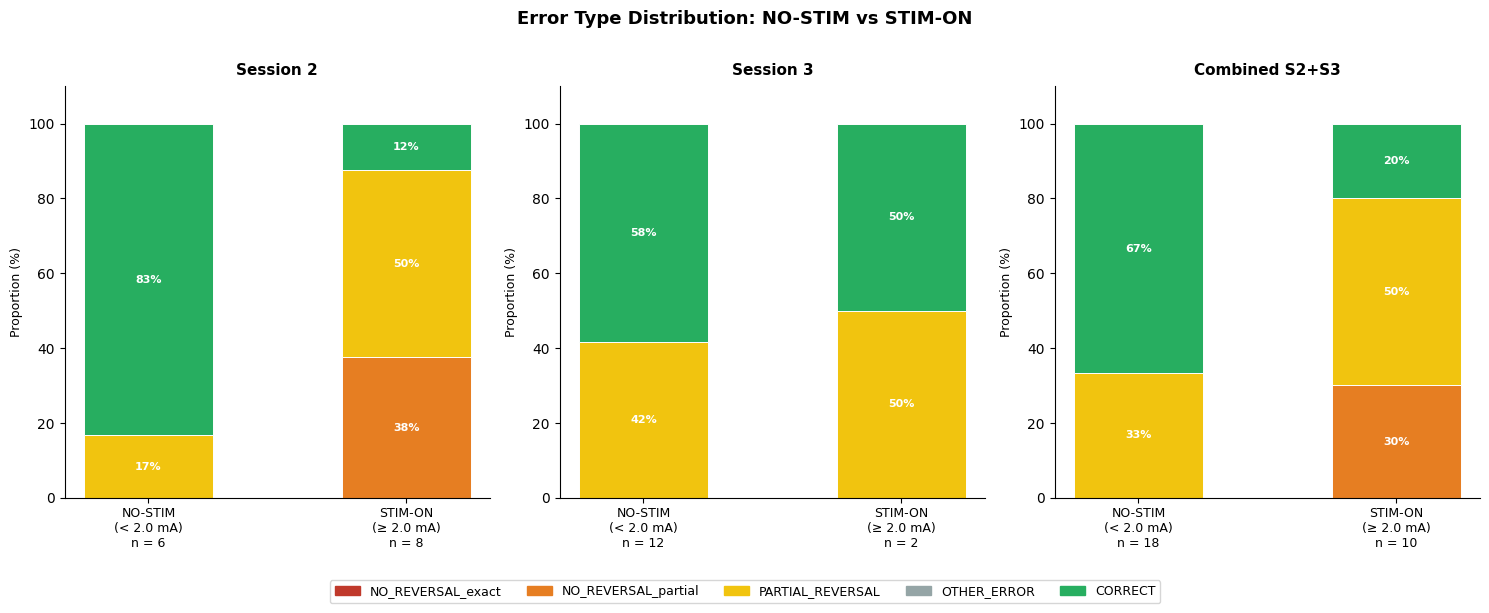

Plot 2 saved: plot2_error_type_breakdown.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 5 — REVERSAL FAILURE × STIM: breakdown by error subtype
#          (NO_REVERSAL_exact / NO_REVERSAL_partial / PARTIAL_REVERSAL)
# ═══════════════════════════════════════════════════════════════════════════

ERROR_SUBTYPES = ['NO_REVERSAL_exact', 'NO_REVERSAL_partial', 'PARTIAL_REVERSAL', 'OTHER_ERROR', 'CORRECT']
SUBTYPE_COLORS = {
    'NO_REVERSAL_exact'    : '#C0392B',
    'NO_REVERSAL_partial'  : '#E67E22',
    'PARTIAL_REVERSAL'     : '#F1C40F',
    'OTHER_ERROR'          : '#95A5A6',
    'CORRECT'              : '#27AE60',
}

def stacked_error_breakdown(df_subset, ax, title):
    """Stacked bar: error type distribution for NO-STIM vs STIM-ON."""
    groups = {
        f'NO-STIM\n(< {STIM_THRESH_MA} mA)': df_subset[~df_subset['stim_on']],
        f'STIM-ON\n(≥ {STIM_THRESH_MA} mA)': df_subset[ df_subset['stim_on']],
    }
    group_labels = list(groups.keys())
    n_groups = len(group_labels)
    bottoms = np.zeros(n_groups)
    bar_width = 0.50

    for etype in ERROR_SUBTYPES:
        vals = []
        for lbl in group_labels:
            g = groups[lbl]
            n = len(g)
            cnt = (g['error_type'] == etype).sum()
            vals.append(cnt / n * 100 if n > 0 else 0)
        bars = ax.bar(np.arange(n_groups), vals, bar_width,
                      bottom=bottoms, color=SUBTYPE_COLORS[etype],
                      label=etype, edgecolor='white', linewidth=0.7)
        # Label if bar is tall enough
        for xi, v, bot in zip(range(n_groups), vals, bottoms):
            if v > 7:
                ax.text(xi, bot + v/2, f'{v:.0f}%',
                        ha='center', va='center', fontsize=8,
                        color='white', fontweight='bold')
        bottoms += np.array(vals)

    ax.set_xticks(np.arange(n_groups))
    xticklabels = []
    for lbl in group_labels:
        n = len(groups[lbl])
        xticklabels.append(f'{lbl}\nn = {n}')
    ax.set_xticklabels(xticklabels, fontsize=9)
    ax.set_ylabel('Proportion (%)', fontsize=9)
    ax.set_ylim(0, 110)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), facecolor='white')
fig.suptitle('Error Type Distribution: NO-STIM vs STIM-ON',
             fontsize=13, fontweight='bold', y=1.01)

for ax, (df_s, lbl) in zip(axes, [(df2, 'Session 2'),
                                    (df3, 'Session 3'),
                                    (df_all, 'Combined S2+S3')]):
    stacked_error_breakdown(df_s, ax, lbl)

handles = [mpatches.Patch(color=SUBTYPE_COLORS[e], label=e)
           for e in ERROR_SUBTYPES]
fig.legend(handles=handles, loc='lower center', ncol=5,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('plot2_error_type_breakdown.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print('Plot 2 saved: plot2_error_type_breakdown.png')

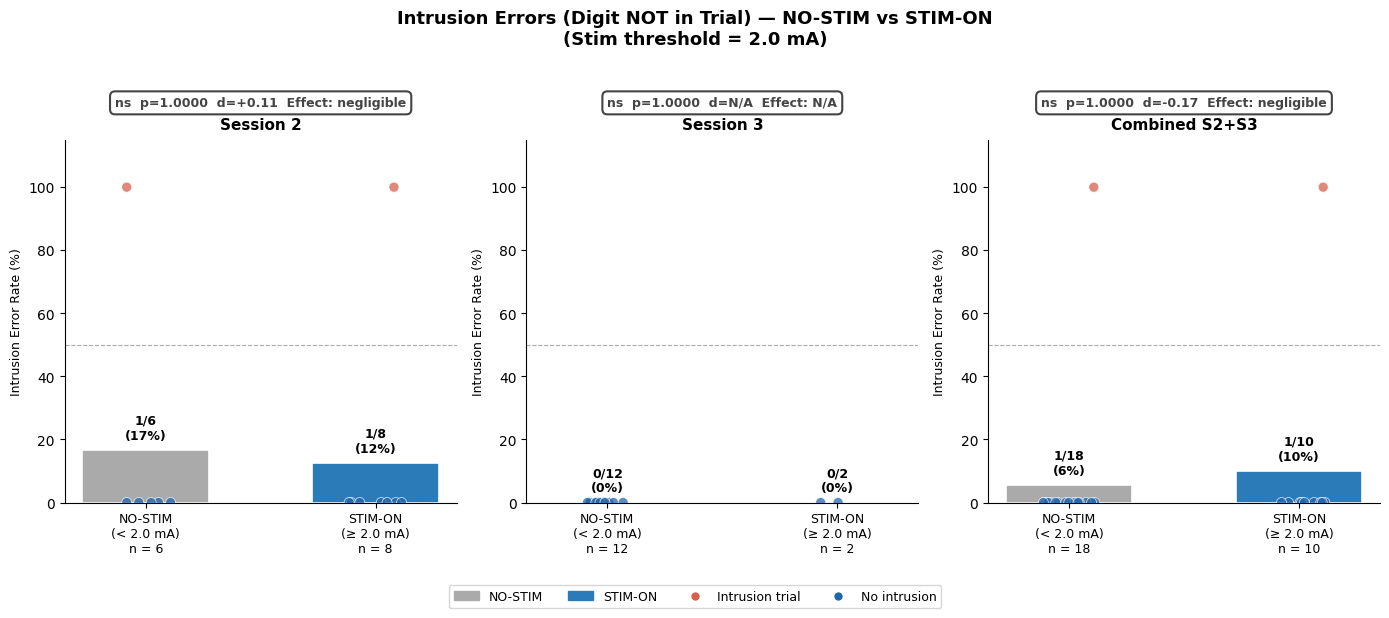

Plot 3 saved: plot3_intrusion_errors.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 6 — INTRUSION ERROR ANALYSIS
#          Trials where patient entered a digit NOT shown in the trial
# ═══════════════════════════════════════════════════════════════════════════

def intrusion_plot(df_subset, ax, title):
    """Bar + jitter: intrusion rate NO-STIM vs STIM-ON."""
    off = df_subset[~df_subset['stim_on']]
    on  = df_subset[ df_subset['stim_on']]

    n_off, n_on = len(off), len(on)
    r_off = off['intrusion'].mean() * 100 if n_off else np.nan
    r_on  = on['intrusion'].mean()  * 100 if n_on  else np.nan

    # Stats
    if n_off >= 1 and n_on >= 1:
        ct = pd.crosstab(df_subset['stim_on'], df_subset['intrusion'])
        for col in [True, False]:
            if col not in ct.columns: ct[col] = 0
        if False in ct.index and True in ct.index:
            _, pval = fisher_exact([[ct.loc[False, True], ct.loc[False, False]],
                                     [ct.loc[True,  True], ct.loc[True,  False]]])
        else:
            pval = np.nan
        d = cohens_d(off['intrusion'].astype(float), on['intrusion'].astype(float))
    else:
        pval, d = np.nan, np.nan

    xs = [0, 1]
    ys = [r_off if not np.isnan(r_off) else 0,
          r_on  if not np.isnan(r_on)  else 0]
    ax.bar(xs, ys, width=0.55, color=[COL_NS, COL_ST],
           edgecolor='white', linewidth=1.2, zorder=2)

    for xi, grp in zip(xs, [off, on]):
        yy  = grp['intrusion'].astype(float) * 100
        jit = np.random.uniform(-0.12, 0.12, len(yy))
        cols = [COL_I if v else COL_C for v in grp['intrusion']]
        ax.scatter(xi + jit, yy, c=cols, s=52, zorder=5,
                   edgecolors='white', linewidths=0.6, alpha=ALPHA_SCATTER)

    ni_off = off['intrusion'].sum()
    ni_on  = on['intrusion'].sum()
    for xi, nb, nt, pct in zip(xs,
                                [ni_off, ni_on],
                                [n_off, n_on],
                                [r_off, r_on]):
        if not np.isnan(pct):
            ax.text(xi, pct + 2.5, f'{int(nb)}/{nt}\n({pct:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    ax.set_xticks(xs)
    ax.set_xticklabels([
        f'NO-STIM\n(< {STIM_THRESH_MA} mA)\nn = {n_off}',
        f'STIM-ON\n(≥ {STIM_THRESH_MA} mA)\nn = {n_on}'
    ], fontsize=9)
    ax.set_ylabel('Intrusion Error Rate (%)', fontsize=9)
    ax.set_ylim(0, 115)
    ax.axhline(50, ls='--', lw=0.8, color='#AAAAAA', zorder=1)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)

    stat_str = format_stat_line(pval, d, n_off, n_on)
    box_col  = stat_box_color(pval, d)
    ax.text(0.5, 1.12, stat_str, transform=ax.transAxes,
            ha='center', va='top', fontsize=9, fontweight='bold',
            color=box_col,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                      edgecolor=box_col, linewidth=1.5))

np.random.seed(42)
fig, axes = plt.subplots(1, 3, figsize=(14, 5.5), facecolor='white')
fig.suptitle('Intrusion Errors (Digit NOT in Trial) — NO-STIM vs STIM-ON\n'
             f'(Stim threshold = {STIM_THRESH_MA} mA)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, (df_s, lbl) in zip(axes, [(df2, 'Session 2'),
                                    (df3, 'Session 3'),
                                    (df_all, 'Combined S2+S3')]):
    intrusion_plot(df_s, ax, lbl)

handles = [
    mpatches.Patch(color=COL_NS, label='NO-STIM'),
    mpatches.Patch(color=COL_ST, label='STIM-ON'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_I,
               markeredgecolor='white', markersize=7, label='Intrusion trial'),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_C,
               markeredgecolor='white', markersize=7, label='No intrusion'),
]
fig.legend(handles=handles, loc='lower center', ncol=4,
           fontsize=9, frameon=True, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('plot3_intrusion_errors.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print('Plot 3 saved: plot3_intrusion_errors.png')

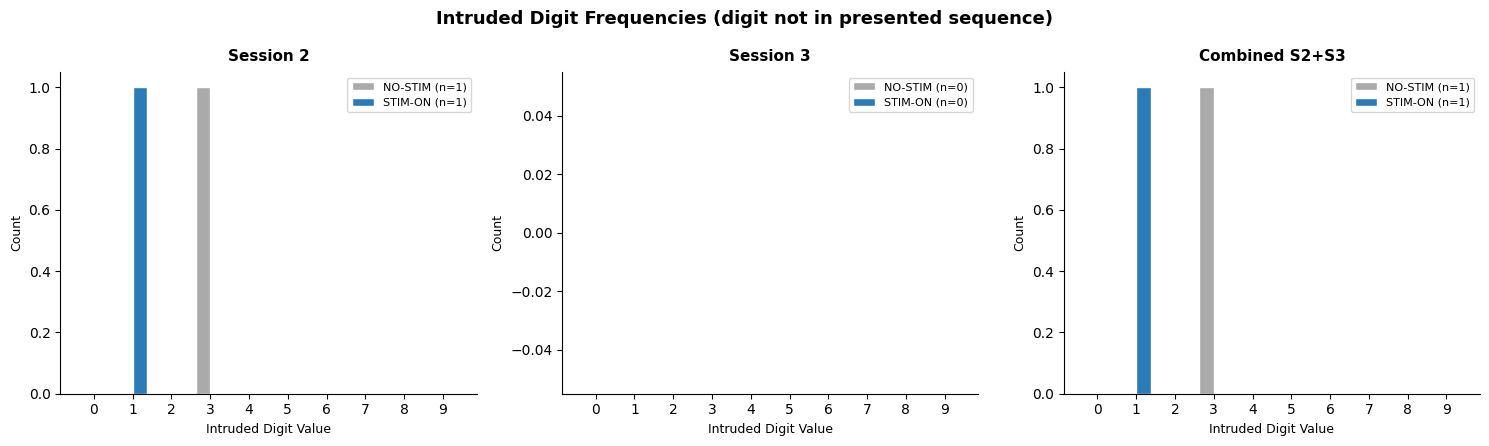

Plot 4 saved: plot4_intrusion_digit_freq.png


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 7 — INTRUSION: WHICH DIGITS WERE INTRUDED?
#          Show frequency of intruded digit values, coloured by stim state
# ═══════════════════════════════════════════════════════════════════════════

def intrusion_digit_freq(df_subset, ax, title):
    """Histogram of intruded digit values split by stim state."""
    intr = df_subset[df_subset['intrusion']]
    off_digs = [d for _, row in intr[~intr['stim_on']].iterrows()
                for d in row['intrusion_digits']]
    on_digs  = [d for _, row in intr[ intr['stim_on']].iterrows()
                for d in row['intrusion_digits']]

    digits = [str(i) for i in range(10)]
    x = np.arange(10)
    w = 0.38
    off_cnt = [off_digs.count(d) for d in digits]
    on_cnt  = [on_digs.count(d)  for d in digits]

    ax.bar(x - w/2, off_cnt, w, label=f'NO-STIM (n={len(off_digs)})',
           color=COL_NS, edgecolor='white')
    ax.bar(x + w/2, on_cnt,  w, label=f'STIM-ON (n={len(on_digs)})',
           color=COL_ST, edgecolor='white')

    ax.set_xticks(x)
    ax.set_xticklabels(digits, fontsize=10)
    ax.set_xlabel('Intruded Digit Value', fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), facecolor='white')
fig.suptitle('Intruded Digit Frequencies (digit not in presented sequence)',
             fontsize=13, fontweight='bold')
for ax, (df_s, lbl) in zip(axes, [(df2, 'Session 2'),
                                    (df3, 'Session 3'),
                                    (df_all, 'Combined S2+S3')]):
    intrusion_digit_freq(df_s, ax, lbl)
plt.tight_layout()
plt.savefig('plot4_intrusion_digit_freq.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print('Plot 4 saved: plot4_intrusion_digit_freq.png')

Saved → plot8a_pairwise_S2.png


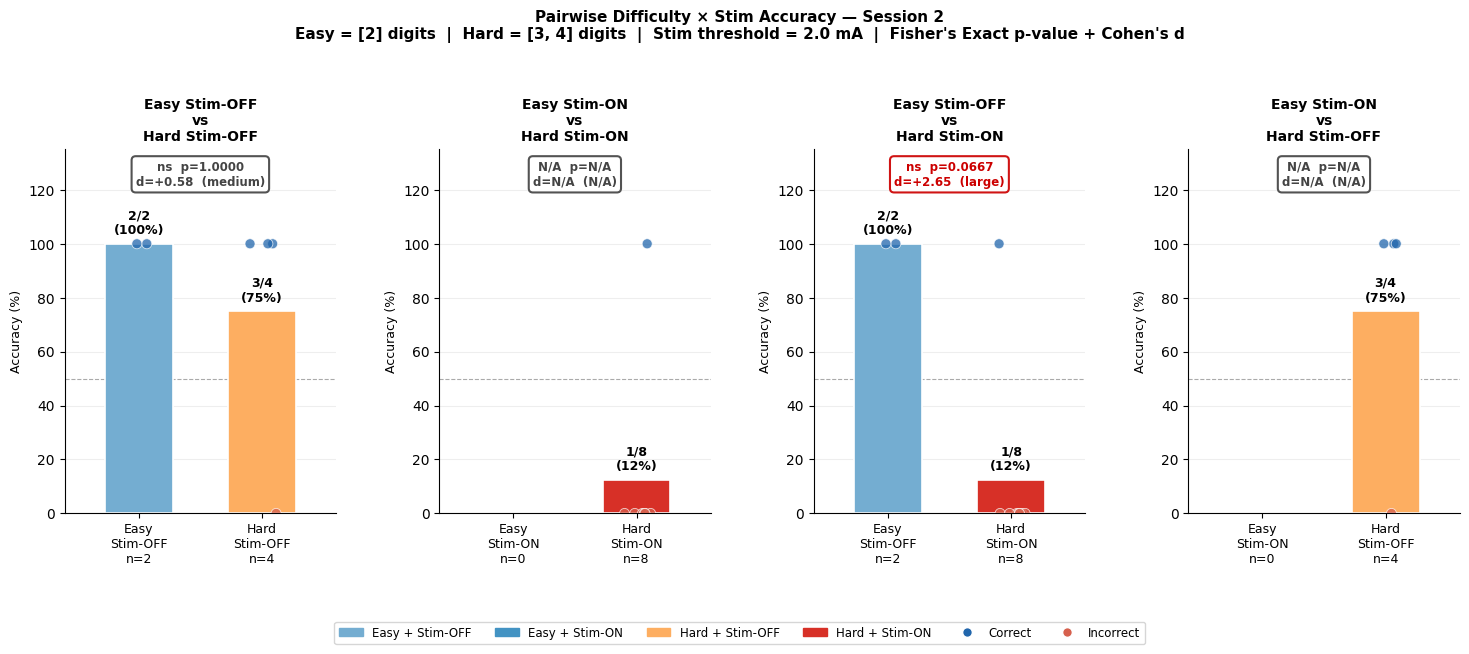

Saved → plot8b_pairwise_S3.png


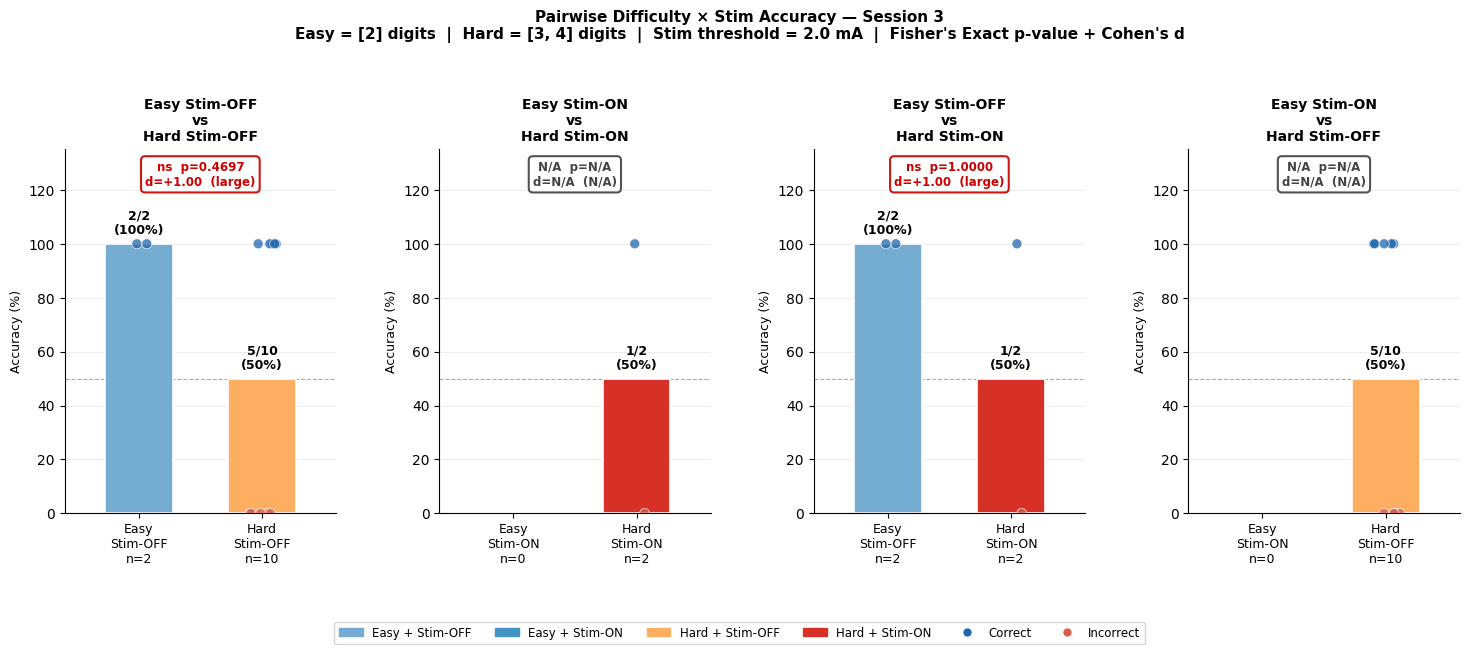

Saved → plot8c_pairwise_combined.png


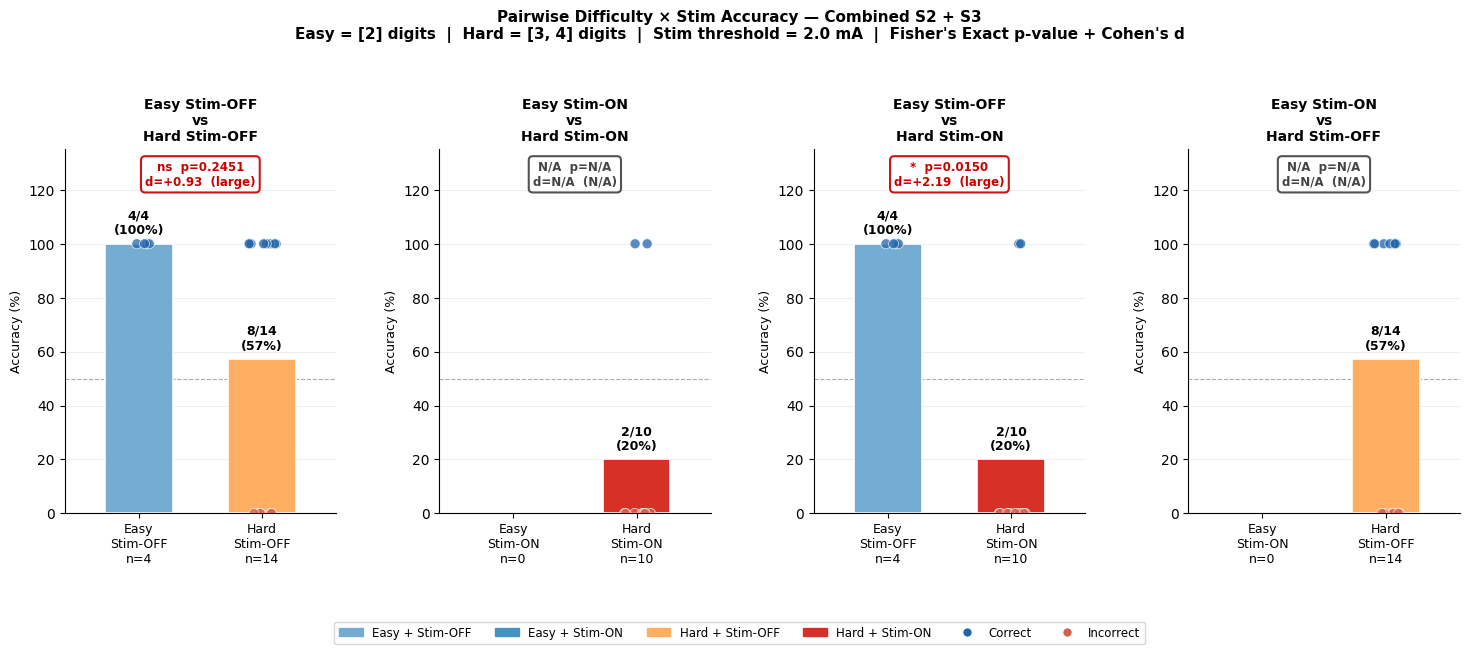

All pairwise plots saved.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 8 — PAIRWISE DIFFICULTY × STIM COMPARISONS
# 4 comparisons × 3 sessions = 12 subplots across 3 figures (1 row × 4 cols)
#
# Comparisons:
#   1. Easy Stim-OFF  vs  Hard Stim-OFF
#   2. Easy Stim-ON   vs  Hard Stim-ON
#   3. Easy Stim-OFF  vs  Hard Stim-ON
#   4. Easy Stim-ON   vs  Hard Stim-OFF
# ═══════════════════════════════════════════════════════════════════════════

COND_COLORS = {
    ('Easy', False): '#74ADD1',
    ('Easy', True) : '#4393C3',
    ('Hard', False): '#FDAE61',
    ('Hard', True) : '#D73027',
}
COND_LABELS = {
    ('Easy', False): 'Easy\nStim-OFF',
    ('Easy', True) : 'Easy\nStim-ON',
    ('Hard', False): 'Hard\nStim-OFF',
    ('Hard', True) : 'Hard\nStim-ON',
}

PAIRS = [
    (('Easy', False), ('Hard', False), 'Easy Stim-OFF\nvs\nHard Stim-OFF'),
    (('Easy', True),  ('Hard', True),  'Easy Stim-ON\nvs\nHard Stim-ON'),
    (('Easy', False), ('Hard', True),  'Easy Stim-OFF\nvs\nHard Stim-ON'),
    (('Easy', True),  ('Hard', False), 'Easy Stim-ON\nvs\nHard Stim-OFF'),
]


def _pairwise_subplot(ax, df_subset, c1, c2, pair_title):
    """Draw one pairwise comparison subplot: 2 bars + jitter + stats."""
    g1 = df_subset[(df_subset['difficulty'] == c1[0]) & (df_subset['stim_on'] == c1[1])]
    g2 = df_subset[(df_subset['difficulty'] == c2[0]) & (df_subset['stim_on'] == c2[1])]

    accs = [
        g1['acc'].mean() * 100 if len(g1) > 0 else np.nan,
        g2['acc'].mean() * 100 if len(g2) > 0 else np.nan,
    ]

    # Bars
    for xi, (g, c, acc_pct) in enumerate(zip([g1, g2], [c1, c2], accs)):
        h = acc_pct if not np.isnan(acc_pct) else 0
        ax.bar(xi, h, width=0.55, color=COND_COLORS[c],
               edgecolor='white', linewidth=1.2, zorder=2)

    # Jitter dots
    rng = np.random.default_rng(seed=42)
    for xi, g in enumerate([g1, g2]):
        yy  = g['acc'].astype(float) * 100
        jit = rng.uniform(-0.12, 0.12, len(yy))
        dot_cols = [COL_C if a else COL_I for a in g['acc']]
        ax.scatter(xi + jit, yy, c=dot_cols, s=52, zorder=5,
                   edgecolors='white', linewidths=0.6, alpha=ALPHA_SCATTER)

    # Count labels
    for xi, (g, acc_pct) in enumerate(zip([g1, g2], accs)):
        if not np.isnan(acc_pct):
            nc, nt = int(g['acc'].sum()), len(g)
            ax.text(xi, acc_pct + 2.5, f'{nc}/{nt}\n({acc_pct:.0f}%)',
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Stats
    if len(g1) >= 1 and len(g2) >= 1:
        a1 = g1['acc'].astype(int).values
        a2 = g2['acc'].astype(int).values
        _, pval = fisher_exact([[a1.sum(), len(a1)-a1.sum()],
                                 [a2.sum(), len(a2)-a2.sum()]])
        d = cohens_d(a1.astype(float), a2.astype(float))
    else:
        pval, d = np.nan, np.nan

    stars = sig_stars(pval)
    p_str = f'p={pval:.4f}' if not np.isnan(pval) else 'p=N/A'
    d_str = f'd={d:+.2f}' if not np.isnan(d) else 'd=N/A'
    eff   = effect_label(d)
    box_c = stat_box_color(pval, d)
    ax.text(0.5, 0.97, f'{stars}  {p_str}\n{d_str}  ({eff})',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=8.5, fontweight='bold', color=box_c,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=box_c, linewidth=1.5, alpha=0.92))

    # x-axis labels
    ax.set_xticks([0, 1])
    ax.set_xticklabels(
        [f'{COND_LABELS[c1]}\nn={len(g1)}',
         f'{COND_LABELS[c2]}\nn={len(g2)}'],
        fontsize=9)
    ax.set_ylabel('Accuracy (%)', fontsize=9)
    ax.set_ylim(0, 135)
    ax.set_xlim(-0.6, 1.6)
    ax.axhline(50, ls='--', lw=0.8, color='#AAAAAA', zorder=1)
    ax.set_title(pair_title, fontsize=10, fontweight='bold', pad=6)
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.grid(True, color='#eeeeee', zorder=0)
    ax.set_axisbelow(True)
    ax.set_facecolor('white')


def plot_pairwise_session(df_subset, sess_label, save_path=None):
    """1 row × 4 col figure for one session."""
    fig, axes = plt.subplots(1, 4, figsize=(18, 6.5), facecolor='white',
                             gridspec_kw=dict(wspace=0.38))

    for ax, (c1, c2, title) in zip(axes, PAIRS):
        _pairwise_subplot(ax, df_subset, c1, c2, title)

    handles = [
        mpatches.Patch(color=COND_COLORS[('Easy', False)], label='Easy + Stim-OFF'),
        mpatches.Patch(color=COND_COLORS[('Easy', True)],  label='Easy + Stim-ON'),
        mpatches.Patch(color=COND_COLORS[('Hard', False)], label='Hard + Stim-OFF'),
        mpatches.Patch(color=COND_COLORS[('Hard', True)],  label='Hard + Stim-ON'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_C,
                   markeredgecolor='white', markersize=7, label='Correct'),
        plt.Line2D([0],[0], marker='o', color='w', markerfacecolor=COL_I,
                   markeredgecolor='white', markersize=7, label='Incorrect'),
    ]
    fig.subplots_adjust(top=0.78, bottom=0.22, wspace=0.42)
    fig.suptitle(
        f'Pairwise Difficulty × Stim Accuracy — {sess_label}\n'
        f'Easy = {EASY_DIGITS} digits  |  Hard = {HARD_DIGITS} digits  |  '
        f'Stim threshold = {STIM_THRESH_MA} mA  |  '
        'Fisher\'s Exact p-value + Cohen\'s d',
        fontsize=11, fontweight='bold', y=0.995)

    fig.legend(handles=handles, loc='lower center', ncol=6,
               fontsize=8.5, frameon=True, bbox_to_anchor=(0.5, 0.01))
    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f'Saved → {save_path}')
    plt.show()
    plt.close(fig)


# ── Run ──────────────────────────────────────────────────────────────────────
np.random.seed(42)
plot_pairwise_session(df2,    'Session 2',          'plot8a_pairwise_S2.png')
plot_pairwise_session(df3,    'Session 3',          'plot8b_pairwise_S3.png')
plot_pairwise_session(df_all, 'Combined S2 + S3',   'plot8c_pairwise_combined.png')
print('All pairwise plots saved.')

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 9 — SUMMARY STATISTICS TABLE
# ═══════════════════════════════════════════════════════════════════════════

rows = []
for sess_label, df_s in [('S2', df2), ('S3', df3), ('S2+S3', df_all)]:

    # 1. Reversal failure
    off = df_s[~df_s['stim_on']]
    on  = df_s[ df_s['stim_on']]
    a1  = off['reversal_failure'].astype(float).values
    a2  = on['reversal_failure'].astype(float).values
    if len(a1) >= 1 and len(a2) >= 1:
        ct = [[int(a1.sum()), int(len(a1)-a1.sum())],
              [int(a2.sum()), int(len(a2)-a2.sum())]]
        _, pval = fisher_exact(ct)
    else:
        pval = np.nan
    d = cohens_d(a1, a2)
    rows.append([sess_label, 'Reversal Failure',
                 f'{a1.mean()*100:.1f}% ({int(a1.sum())}/{len(a1)})',
                 f'{a2.mean()*100:.1f}% ({int(a2.sum())}/{len(a2)})',
                 f'{pval:.4f}' if not np.isnan(pval) else 'N/A',
                 f'{d:+.2f}' if not np.isnan(d) else 'N/A',
                 effect_label(d),
                 sig_stars(pval)])

    # 2. Intrusion
    a1i = off['intrusion'].astype(float).values
    a2i = on['intrusion'].astype(float).values
    if len(a1i) >= 1 and len(a2i) >= 1:
        ct = [[int(a1i.sum()), int(len(a1i)-a1i.sum())],
              [int(a2i.sum()), int(len(a2i)-a2i.sum())]]
        _, pval_i = fisher_exact(ct)
    else:
        pval_i = np.nan
    di = cohens_d(a1i, a2i)
    rows.append([sess_label, 'Intrusion Error',
                 f'{a1i.mean()*100:.1f}% ({int(a1i.sum())}/{len(a1i)})',
                 f'{a2i.mean()*100:.1f}% ({int(a2i.sum())}/{len(a2i)})',
                 f'{pval_i:.4f}' if not np.isnan(pval_i) else 'N/A',
                 f'{di:+.2f}' if not np.isnan(di) else 'N/A',
                 effect_label(di),
                 sig_stars(pval_i)])

    # 3–6. Difficulty pairs
    diff_pairs = [
        ('Easy OFF vs Easy ON',
         df_s[(df_s['difficulty']=='Easy') & ~df_s['stim_on']]['acc'].astype(float).values,
         df_s[(df_s['difficulty']=='Easy') &  df_s['stim_on']]['acc'].astype(float).values),
        ('Hard OFF vs Hard ON',
         df_s[(df_s['difficulty']=='Hard') & ~df_s['stim_on']]['acc'].astype(float).values,
         df_s[(df_s['difficulty']=='Hard') &  df_s['stim_on']]['acc'].astype(float).values),
        ('ON: Easy vs Hard',
         df_s[(df_s['difficulty']=='Easy') &  df_s['stim_on']]['acc'].astype(float).values,
         df_s[(df_s['difficulty']=='Hard') &  df_s['stim_on']]['acc'].astype(float).values),
        ('OFF: Easy vs Hard',
         df_s[(df_s['difficulty']=='Easy') & ~df_s['stim_on']]['acc'].astype(float).values,
         df_s[(df_s['difficulty']=='Hard') & ~df_s['stim_on']]['acc'].astype(float).values),
    ]
    for comp_lbl, b1, b2 in diff_pairs:
        if len(b1) >= 1 and len(b2) >= 1:
            ct = [[int(b1.sum()), int(len(b1)-b1.sum())],
                  [int(b2.sum()), int(len(b2)-b2.sum())]]
            _, pv = fisher_exact(ct)
        else:
            pv = np.nan
        dv = cohens_d(b1, b2)
        rows.append([sess_label, comp_lbl,
                     f'{b1.mean()*100:.1f}% ({int(b1.sum())}/{len(b1)})' if len(b1) else 'N/A',
                     f'{b2.mean()*100:.1f}% ({int(b2.sum())}/{len(b2)})' if len(b2) else 'N/A',
                     f'{pv:.4f}' if not np.isnan(pv) else 'N/A',
                     f'{dv:+.2f}' if not np.isnan(dv) else 'N/A',
                     effect_label(dv),
                     sig_stars(pv)])

stats_df = pd.DataFrame(rows, columns=[
    'Session', 'Comparison',
    'Group 1 (OFF / Easy / 1st)',
    'Group 2 (ON  / Hard / 2nd)',
    'p-value', "Cohen's d", 'Effect Size', 'Sig'
])

print('\n' + '='*90)
print('SUMMARY STATISTICS TABLE')
print('='*90)
print(stats_df.to_string(index=False))

# Save as CSV
stats_df.to_csv('summary_stats_table.csv', index=False)
print('\nSaved: summary_stats_table.csv')


SUMMARY STATISTICS TABLE
Session          Comparison Group 1 (OFF / Easy / 1st) Group 2 (ON  / Hard / 2nd) p-value Cohen's d Effect Size Sig
     S2    Reversal Failure                16.7% (1/6)                87.5% (7/8)  0.0256     -1.88       large   *
     S2     Intrusion Error                16.7% (1/6)                12.5% (1/8)  1.0000     +0.11  negligible  ns
     S2 Easy OFF vs Easy ON               100.0% (2/2)                        N/A     N/A       N/A         N/A N/A
     S2 Hard OFF vs Hard ON                75.0% (3/4)                12.5% (1/8)  0.0667     +1.55       large  ns
     S2    ON: Easy vs Hard                        N/A                12.5% (1/8)     N/A       N/A         N/A N/A
     S2   OFF: Easy vs Hard               100.0% (2/2)                75.0% (3/4)  1.0000     +0.58      medium  ns
     S3    Reversal Failure               41.7% (5/12)                50.0% (1/2)  1.0000     -0.16  negligible  ns
     S3     Intrusion Error                0.0

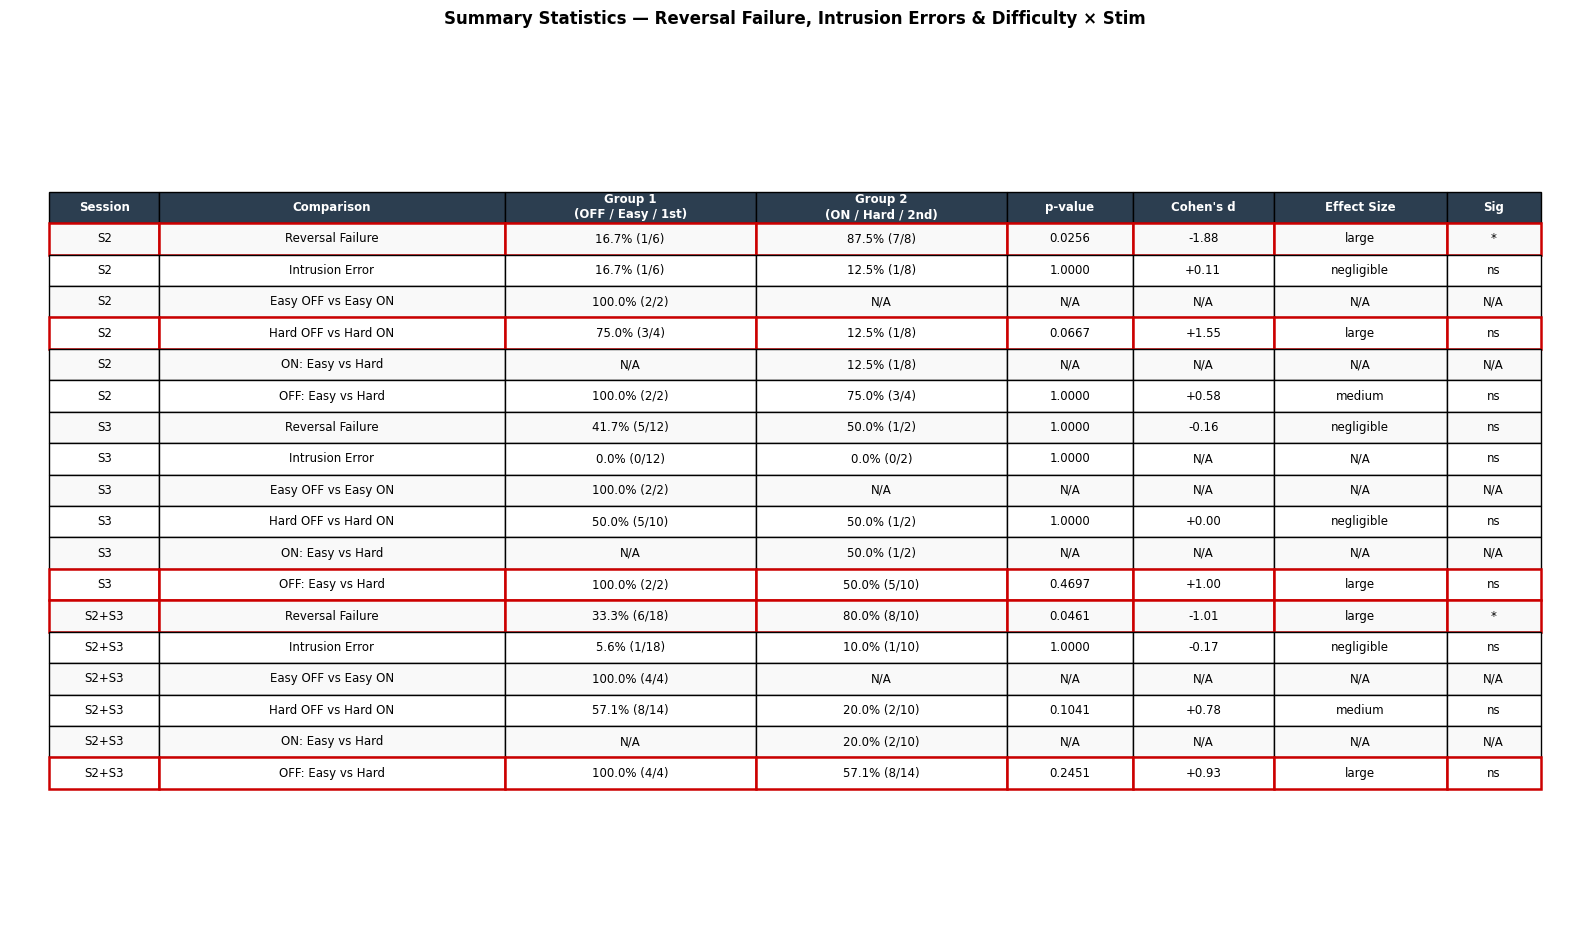

Plot 6 saved: plot6_stats_table.png

✓ All analyses complete.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# CELL 10 — SUMMARY TABLE FIGURE (visual, for reports)
# ═══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(16, len(stats_df)*0.45 + 1.5), facecolor='white')
ax.axis('off')

cols_show = ['Session', 'Comparison',
             'Group 1\n(OFF / Easy / 1st)',
             'Group 2\n(ON / Hard / 2nd)',
             'p-value', "Cohen's d", 'Effect Size', 'Sig']
col_widths = [0.07, 0.22, 0.16, 0.16, 0.08, 0.09, 0.11, 0.06]

cell_data = stats_df.values.tolist()
tbl = ax.table(
    cellText=cell_data,
    colLabels=cols_show,
    colWidths=col_widths,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1, 1.55)

# Header style
for j in range(len(cols_show)):
    tbl[0, j].set_facecolor('#2C3E50')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

# Highlight significant rows
for i, row in enumerate(cell_data):
    bg = '#F9F9F9' if i % 2 == 0 else 'white'
    for j in range(len(cols_show)):
        tbl[i+1, j].set_facecolor(bg)
    try:
        pv = float(row[4])
        dv_str = row[5].replace('+','').replace('N/A','nan')
        dv = float(dv_str)
        if pv < 0.05 or abs(dv) >= 0.8:
            for j in range(len(cols_show)):
                tbl[i+1, j].set_edgecolor('#CC0000')
                tbl[i+1, j].set_linewidth(1.8)
    except Exception:
        pass

ax.set_title(
    'Summary Statistics — Reversal Failure, Intrusion Errors & Difficulty × Stim',
    fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('plot6_stats_table.png', dpi=150,
            bbox_inches='tight', facecolor='white')
plt.show()
plt.close(fig)
print('Plot 6 saved: plot6_stats_table.png')
print('\n✓ All analyses complete.')